# Vorlage Plausi-Tests

### Anteil Ausländer*innen, seit 1901

Beschreibung
Anteil Ausländer*innen der Stadt Zürich nach Jahr, seit 1901.


Datum: 15.03.2023

**Dataset auf INTEG Datenkatalog**:  https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_anteil_auslaenderinnen_jahr_od3226

**Dataset auf PROD Datenkatalog**:  https://data.stadt-zuerich.ch/dataset/bev_anteil_auslaenderinnen_jahr_od3226

### Importiere die notwendigen Packages

In [54]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly

In [55]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns



In [56]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [57]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [58]:
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

Settings für Matplotlib

In [59]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

### Zeitvariabeln
Bestimme den aktuellst geladenen Monat. Hier ist es der Stand vor 2 Monaten. 
Bestimme noch weitere evt. sinnvolle Zeitvariabeln.

Zum Unterschied zwischen import datetime und from datedtime import datetime, siehe https://stackoverflow.com/questions/15707532/import-datetime-v-s-from-datetime-import-datetime

Zuerst die Zeitvariabeln als Strings

In [60]:
now = datetime.date.today()
date_today = now.strftime("%Y-%m-%d")
year_today = now.strftime("%Y")
month_today = now.strftime("%m")
day_today = now.strftime("%d")

date_day_a_week_ago = (datetime.datetime.now() - datetime.timedelta(days=7)).date()
day_a_week_ago = date_day_a_week_ago.strftime('%Y-%m-%d')


print(now," vor einer Woche: ", day_a_week_ago)


2024-03-10  vor einer Woche:  2024-03-03


#### Und hier noch die Zeitvariabeln als Integers:
- `aktuellesJahr`
- `aktuellerMonat`: Der gerade jetzt aktuelle Monat
- `selectedMonat`: Der aktuellste Monat in den Daten. In der Regel zwei Monate her.

In [61]:
#now = datetime.now() 
int_times = now.timetuple()

aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2

print(aktuellesJahr, 
      aktuellerMonat,
    'datenstand: ', selectedMonat,
     int_times)



2024 3 datenstand:  1 time.struct_time(tm_year=2024, tm_mon=3, tm_mday=10, tm_hour=0, tm_min=0, tm_sec=0, tm_wday=6, tm_yday=70, tm_isdst=-1)


### Setze einige Pfadvariabeln

- Der Packagename ist eigentlich der **Verzeichnisname** unter dem die Daten und Metadaten auf der Dropzone abgelegt werden.
- Definiert wird er bei SASA-Prozessen auf dem **Produkte-Sharepoint ([Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/PersonalViews.aspx?PageView=Personal&ShowWebPart={6087A3E7-8AC8-40BA-8278-DECFACE124FF}))**.
- Der Packagename wird auf CKAN teil der URL, daher ist die exakte Schreibweise wichtig.

Beachte: im Packagename müssen alle Buchstaben **klein** geschrieben werden. Dies weil CKAN aus grossen kleine Buchstaben macht.

##### `HIER ANPASSEN`

In [62]:
package_name = "bev_anteil_auslaenderinnen_jahr_od3226"
dataset_name = "BEV322OD3226.csv"

**Statische Pfade in DWH-Dropzones und CKAN-URLs**

In [63]:
dropzone_path_integ = r"\\szh\ssz\applikationen\OGD_Dropzone\INT_DWH"
dropzone_path_prod = r"\\szh\ssz\applikationen\OGD_Dropzone\DWH"
ckan_integ_url ="https://data.integ.stadt-zuerich.ch/dataset/int_dwh_"
ckan_prod_url ="https://data.stadt-zuerich.ch/dataset/"

### Checke die Metadaten auf der CKAN INTEG- oder PROD-Webseite

Offenbar lassen sich aktuell im Markdownteil keine Variabeln ausführen, daher gehen wir wie unten gezeigt vor. Siehe dazu: https://data-dive.com/jupyterlab-markdown-cells-include-variables
Instead of setting the cell to Markdown, create Markdown from withnin a code cell! We can just use python variable replacement syntax to make the text dynamic

In [64]:
from IPython.display import Markdown as md

In [65]:
md(" **1. Dataset auf INTEG-Datakatalog:** Link {} ".format(ckan_integ_url+package_name))

 **1. Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_anteil_auslaenderinnen_jahr_od3226 

In [66]:
md(" **2. Dataset auf PROD-Datakatalog:** Link {} ".format(ckan_prod_url+package_name))

 **2. Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_anteil_auslaenderinnen_jahr_od3226 

### Importiere einen Datensatz 

Definiere zuerst folgende Werte:
1) Kommt der Datensatz von PROD oder INTEG?
2) Beziehst Du den Datensatz direkt ab der DROPZONE oder aus dem INTERNET?

In [67]:
#Die Datasets sind nur zum Testen auf INT-DWH-Dropzone. Wenn der Test vorbei ist, sind sie auf PROD. 
# Über den Status kann man einfach switchen

status = "integ"; #prod vs something else
data_source = "web"; #dropzone vs something else
print(status+" - "+ data_source)

integ - web


In [68]:
# Filepath
if status == "prod":
    if data_source == "dropzone":
            fp = dropzone_path_prod+"\\"+ package_name +"\\"+dataset_name
            print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_prod_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)
else:
    if data_source == "dropzone":
        fp = dropzone_path_integ+"\\"+ package_name +"\\"+dataset_name
        print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_integ_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)


fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_anteil_auslaenderinnen_jahr_od3226/download/BEV322OD3226.csv


In [69]:
# Read the data
if data_source == "dropzone":
    data2betested = pd.read_csv(
        fp
        , sep=','
        ,parse_dates=['StichtagDatJahr']
        ,low_memory=False
    )
    print("dropzone")
else:
    r = requests.get(fp, verify=False)  
    r.encoding = 'utf-8'
    data2betested = pd.read_csv(
        io.StringIO(r.text)
        ,parse_dates=['StichtagDatJahr']
        # KONVERTIERE DAS SAS DATUM IN EIN UNIXDATUM UND FORMATIERE ES
        #, date_parser=lambda s: epoch + datetime.timedelta(days=int(s))
        ,low_memory=False)
    print("web")

data2betested.dtypes

web


StichtagDatJahr    datetime64[ns]
DatenstandCd               object
HerkunftCd                  int64
HerkunftLang               object
AuslAnt                   float64
dtype: object

Berechne weitere Attribute falls notwendig

In [70]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
        
    )
    .sort_values('Jahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr    datetime64[ns]
DatenstandCd               object
HerkunftCd                  int64
HerkunftLang               object
AuslAnt                   float64
Jahr               datetime64[ns]
Jahr_str                   object
Jahr_nbr                    int64
dtype: object

Minimales und maximales Jahr im Datensatz

In [71]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1901 und ein Maximumjahr von 2023


### Einfache Datentests

In [72]:
data2betested.sort_values("AuslAnt",ascending=True).head(2).T

,44,43
StichtagDatJahr,1945-01-01 00:00:00,1944-01-01 00:00:00
DatenstandCd,D,D
HerkunftCd,2,2
HerkunftLang,Ausländer*in,Ausländer*in
AuslAnt,7,7
Jahr,1945-01-01 00:00:00,1944-01-01 00:00:00
Jahr_str,1945-01-01,1944-01-01
Jahr_nbr,1945,1944


In [73]:
#data2betested.dtypes
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 123 entries, 122 to 0
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   StichtagDatJahr  123 non-null    datetime64[ns]
 1   DatenstandCd     123 non-null    object        
 2   HerkunftCd       123 non-null    int64         
 3   HerkunftLang     123 non-null    object        
 4   AuslAnt          123 non-null    float64       
 5   Jahr             123 non-null    datetime64[ns]
 6   Jahr_str         123 non-null    object        
 7   Jahr_nbr         123 non-null    int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(3)
memory usage: 32.0 KB


In [74]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 123 rows (observations) and 8 columns (variables).
There seem to be 0 exact duplicates in the data.


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [75]:
data2betested = data2betested.set_index("Jahr")
data2betested = data2betested.sort_index()
#data2betested = data2betested.reset_index()

In [76]:
data2betested.index.year.unique()

Int64Index([1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910,
            ...
            2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
           dtype='int64', name='Jahr', length=123)

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [77]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

,StichtagDatJahr,DatenstandCd,HerkunftLang,Jahr_str
count,123,123,123,123
unique,NaN,2,1,123
top,NaN,D,Ausländer*in,1901-01-01
freq,NaN,93,123,1
mean,1961-12-31 21:04:23.414634144,NaN,NaN,NaN
min,1901-01-01 00:00:00,NaN,NaN,NaN
25%,1931-07-02 12:00:00,NaN,NaN,NaN
50%,1962-01-01 00:00:00,NaN,NaN,NaN
75%,1992-07-02 00:00:00,NaN,NaN,NaN
max,2023-01-01 00:00:00,NaN,NaN,NaN


Beschreibe numerische Attribute

In [78]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,HerkunftCd,AuslAnt,Jahr_nbr
count,123,123,123
mean,2,21,"1,962"
std,0,9,36
min,2,7,"1,901"
25%,2,15,"1,932"
50%,2,20,"1,962"
75%,2,30,"1,992"
max,2,34,"2,023"


#### Nullwerte und Missings?

Wie viele Nullwerte gibt es im Datensatz?

In [79]:
data2betested.isnull().sum()

StichtagDatJahr    0
DatenstandCd       0
HerkunftCd         0
HerkunftLang       0
AuslAnt            0
Jahr_str           0
Jahr_nbr           0
dtype: int64

### Gibt es Duplikate?

In [80]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,StichtagDatJahr,DatenstandCd,HerkunftCd,HerkunftLang,AuslAnt,Jahr_str,Jahr_nbr
Jahr,,,,,,,


In [81]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

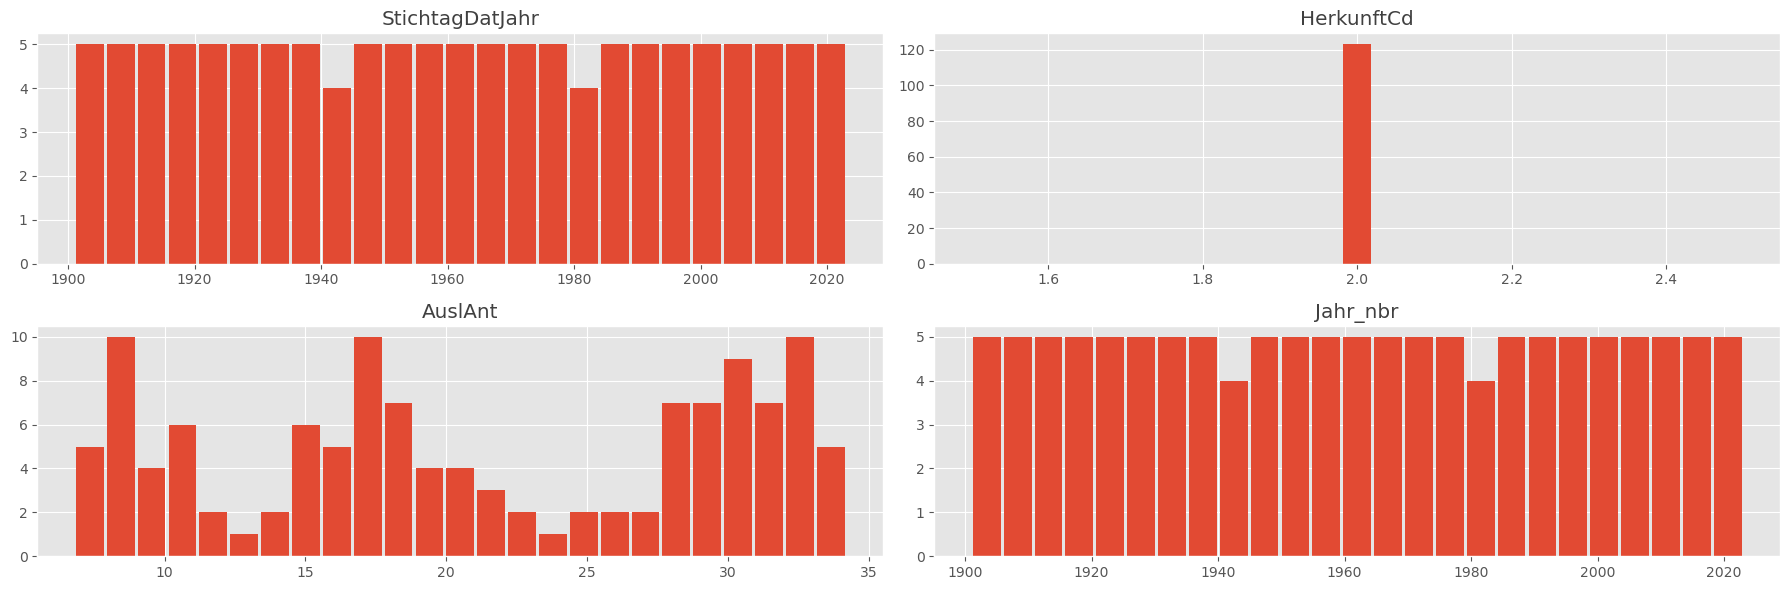

In [82]:
# plot a histogram for each numerical feature
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gruppierungen

In [86]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr']) \
    .agg(meanAnzBestWir=('AuslAnt', 'mean')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,meanAnzBestWir
0,2023-01-01,34
1,2022-01-01,33
2,2021-01-01,32


In [87]:
data2betested.columns

Index(['StichtagDatJahr', 'DatenstandCd', 'HerkunftCd', 'HerkunftLang', 'AuslAnt', 'Jahr_str',
       'Jahr_nbr'],
      dtype='object')

In [89]:
agg_AA = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftCd', 'HerkunftLang']) \
    .agg(mean_AuslAnt=('AuslAnt', 'mean')) \
    .sort_values('HerkunftCd', ascending=False) 
agg_AA.reset_index().head(40)

,HerkunftCd,HerkunftLang,mean_AuslAnt
0,2,Ausländer*in,21


### Einfache Visualisierungen zur Plausi

Exploriere die Daten mit Pivottable.JS

In [ ]:
#pivot_ui(data2betested)

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [90]:
data2betested.loc[data_max_date].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,StichtagDatJahr,DatenstandCd,HerkunftCd,HerkunftLang,AuslAnt,Jahr_str,Jahr_nbr
Jahr,,,,,,,
2023-01-01,2023-01-01,D,2,Ausländer*in,34,2023-01-01,2023


### Visualisierungen nach Zeitausschnitten

#### Entwicklung der Wohnbevölkerung nach Staatsangehörigkeit, seit 1993

In [91]:
data2betested.columns

Index(['StichtagDatJahr', 'DatenstandCd', 'HerkunftCd', 'HerkunftLang', 'AuslAnt', 'Jahr_str',
       'Jahr_nbr'],
      dtype='object')

In [101]:

myAggBar = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr_nbr','Jahr', 'HerkunftCd', 'HerkunftLang']) \
    .agg(mean_AuslAnt=('AuslAnt', 'mean')) \
    .sort_values('HerkunftCd', ascending=False) 
myAggBar.reset_index().head(2)
#myAgg.reset_index().melt()

,Jahr_nbr,Jahr,HerkunftCd,HerkunftLang,mean_AuslAnt
0,1901,1901-01-01,2,Ausländer*in,28
1,1993,1993-01-01,2,Ausländer*in,27


In [96]:
myTitle="Entwicklung des Ausländeranteils, "+data_min_date + "- "+data_max_date

highlight = alt.selection(type='single', on='mouseover',
                          fields=['HerkunftLang'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAggBar.reset_index(), title=myTitle).encode(
    x=alt.X('Jahr_nbr', axis=alt.Axis(title='Anteil'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('mean_AuslAnt', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('HerkunftLang', legend=alt.Legend(title="Kontinent", orient="right"))  
    ,tooltip=['Jahr_nbr', 'HerkunftLang','mean_AuslAnt']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=750 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(1.2), alt.value(4))
).interactive()

lines + points

alt.LayerChart(...)

#### Barcharts mit Seaborn

In [97]:
myAggBar.reset_index().dtypes


Jahr_nbr          int64
HerkunftCd        int64
HerkunftLang     object
mean_AuslAnt    float64
dtype: object

In [98]:
#help(sns.catplot)  
#Stile for the following sns graphs
sns.set_theme(style="whitegrid")   

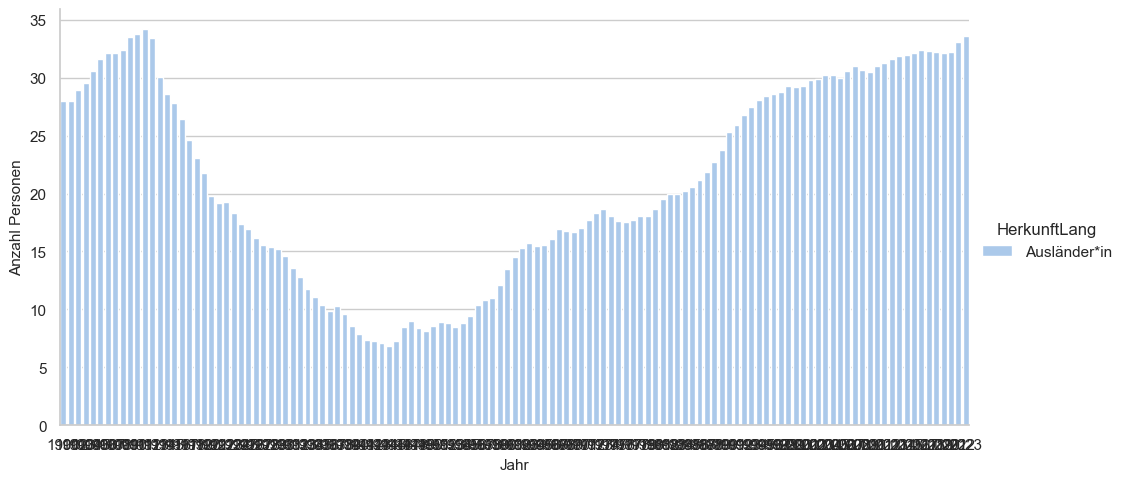

In [103]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="Jahr_nbr"
            , y="mean_AuslAnt"
            , hue="HerkunftLang"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=myAggBar.reset_index()
           )
myHist.set_xlabels('Jahr', fontsize=11) # not set_label
myHist.set_ylabels('Anzahl Personen', fontsize=11)


**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/_layouts/15/listform.aspx?PageType=4&ListId=%7BCB786184%2D948E%2D434B%2D98D5%2D3731AB652A28%7D&ID=1243&ContentTypeID=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

## ---------------------- hier Plausi beendet

Liniendiagramm 
[Link zur Doku](https://altair-viz.github.io/gallery/multiline_highlight.html)

### Test: Choroplethenkarte
Importiere die Geodaten als GeoJSON

#### Stadtkreise

In [ ]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
geojson_url_kreise = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Stadtkreise?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_stadtkreise_v"
adm_stadtkreise_v = gpd.read_file(geojson_url_kreise)

adm_stadtkreise_v.head(1)


,id,kname,knr,objid,geometry
0,adm_stadtkreise_v.1,Kreis 6,6,1,"POLYGON ((8.52602 47.40844, 8.52625 47.40855, ..."


#### Statistische Zonen

In [ ]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
geojson_url_statzonen = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Zonen?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statzonen_map"
adm_statzonen_map = gpd.read_file(geojson_url_statzonen)

adm_statzonen_map.head(2)


,id,kname,knr,objectid,objid,qname,qnr,stzname,stznr,geometry
0,adm_statzonen_map.1,Kreis 7,7,1,154,Hirslanden,73,Hegibach,7303,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ..."
1,adm_statzonen_map.2,Kreis 7,7,2,89,Hirslanden,73,Klus,7302,"POLYGON ((8.57281 47.35806, 8.57278 47.35807, ..."


#### Statistische Quartiere

In [ ]:
geojson_url_quartiere = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_map"
df_adm_statistische_quartiere_map = gpd.read_file(geojson_url_quartiere)

df_adm_statistische_quartiere_map.head(2)


,id,kname,knr,objectid,objid,qname,qnr,geometry
0,adm_statistische_quartiere_map.1,Kreis 7,7,1,34,Hirslanden,73,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ..."
1,adm_statistische_quartiere_map.2,Kreis 8,8,2,33,Weinegg,83,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ..."


### Joins
Joine die importierten statistischen Daten des aktuellen Jahres zum Geodatensatz:

*Siehe dazu Doku zu [Geopandas](https://geopandas.org/docs/user_guide/mergingdata.html)*

In [ ]:
data2betested.dtypes

StichtagDatJahr    datetime64[ns]
QuarSort                    int64
QuarCd                      int64
QuarLang                   object
NationHistSort              int64
NationHistLang             object
NationSort                  int64
NationLang                 object
RegionSort                  int64
RegionLang                 object
KontinentSort               int64
KontinentLang              object
AnzBestWir                  int64
Jahr_str                   object
Jahr_nbr                    int64
dtype: object

In [ ]:
myAgg = data2betested.loc["2021"]  \
    .groupby(['QuarLang', 'QuarCd']) \
    .agg(sum_Whg_abgebrochen=('Whg_abgebrochen', 'sum'),sum_Whg_fertigerstellt=('Whg_fertigerstellt', 'sum')) \
    .sort_values('sum_Whg_abgebrochen', ascending=False) 

myAgg.reset_index().head(1)


KeyError: "Column(s) ['Whg_abgebrochen', 'Whg_fertigerstellt'] do not exist"

In [ ]:
# Rename attribute stznr to StatZoneSort, so the IDs have the same name
gdf_adm_statistische_quartiere_map = df_adm_statistische_quartiere_map[['geometry', 'qnr', 'qname', 'knr']].rename(columns={'qnr': 'QuarCd'})
gdf_adm_statistische_quartiere_map.head(1)

,geometry,QuarCd,qname,knr
0,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ...",73,Hirslanden,7


In [ ]:
# Merge with `merge` method on shared variable (stznr und StatZoneSort):
gdf_adm_statistische_quartiere_map_joined = gdf_adm_statistische_quartiere_map.merge(myAgg, on='QuarCd')
gdf_adm_statistische_quartiere_map_joined.head(2)


,geometry,QuarCd,qname,knr,sum_Whg_abgebrochen,sum_Whg_fertigerstellt
0,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ...",73,Hirslanden,7,48,2
1,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ...",83,Weinegg,8,2,0


<AxesSubplot:>

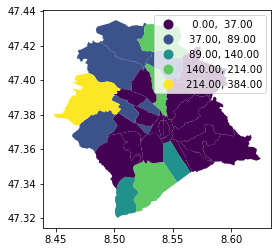

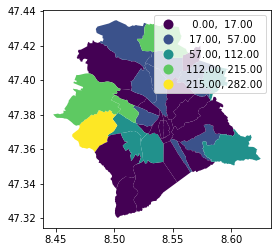

In [ ]:
# Plot by StatQuartiere
# Weitere Schemes: scheme='quantiles', scheme='fisherjenks', scheme='natural_breaks',

gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_fertigerstellt', cmap='viridis', scheme='natural_breaks', legend=True )
gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_abgebrochen', cmap='viridis', scheme='natural_breaks', legend=True )

#gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_abgebrochen', cmap='plasma', scheme='fisherjenks', legend=True )
#gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_fertigerstellt', cmap='cool', scheme='quantiles', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

#
#Neuere Gallerie: https://matplotlib.org/stable/gallery/index.html

<AxesSubplot:>

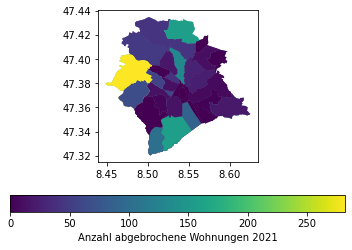

In [ ]:
fig, ax = plt.subplots(1, 1)

gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_abgebrochen', ax=ax, legend=True, legend_kwds={'label': "Anzahl abgebrochene Wohnungen 2021",'orientation': "horizontal"})
gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_fertigerstellt', ax=ax, legend=False, legend_kwds={'label': "Anzahl fertigerstellte Wohnungen 2021",'orientation': "horizontal"})

#gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_abgebrochen', cmap='viridis', scheme='natural_breaks', legend=True , ax=ax, legend_kwds={'label': "Anzahl Personen",'orientation': "horizontal"})

Noch zu prüfen, folgendes schöne Beispiel: https://docs.bokeh.org/en/latest/docs/user_guide/interaction/legends.html

Konkrete Beispiele von Bookeh in Jupyter NB: https://docs.bokeh.org/en/latest/docs/user_guide/jupyter.html